<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 14, accumulation steps = 1 (effective batch size ≈ 14, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.1080 acc 0.535 | val loss 0.7097 acc 0.688 *


[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 0.8690 acc 0.660 | val loss 0.6168 acc 0.754 *


[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.8613 acc 0.690 | val loss 0.6773 acc 0.734


[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.8271 acc 0.664 | val loss 0.7479 acc 0.702


[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.7349 acc 0.735 | val loss 0.5600 acc 0.815 *


...

[DenseNet-121] Epoch  29/100 | LR: 2.74e-08 | train loss 0.2260 acc 0.899 | val loss 0.3727 acc 0.895


[DenseNet-121] Epoch  30/100 | LR: 2.74e-08 | train loss 0.1922 acc 0.918 | val loss 0.3761 acc 0.902


[DenseNet-121] Epoch  31/100 | LR: 2.74e-08 | train loss 0.2166 acc 0.908 | val loss 0.3788 acc 0.902


[DenseNet-121] Epoch  32/100 | LR: 2.74e-08 | train loss 0.2490 acc 0.908 | val loss 0.3708 acc 0.898


[DenseNet-121] Epoch  33/100 | LR: 2.74e-08 | train loss 0.2354 acc 0.908 | val loss 0.3970 acc 0.883

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 33.

[DenseNet-121] Restored best checkpoint (val loss = 0.3565)


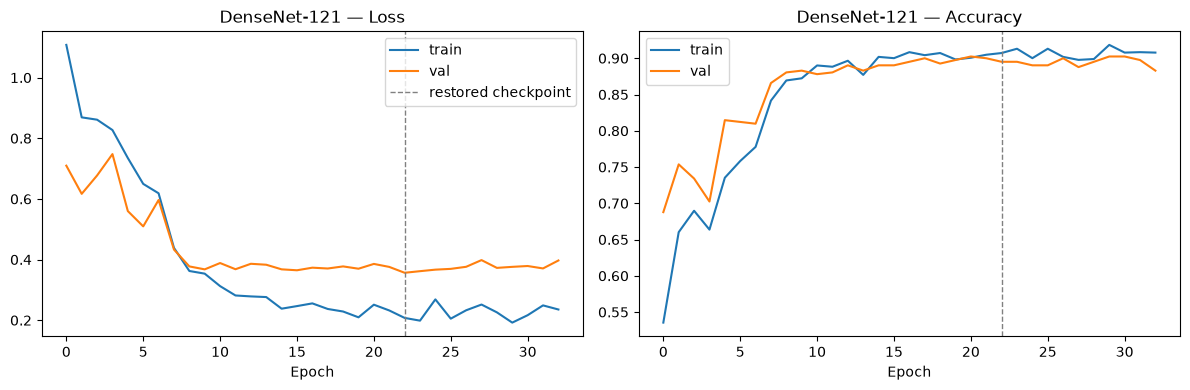

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.862


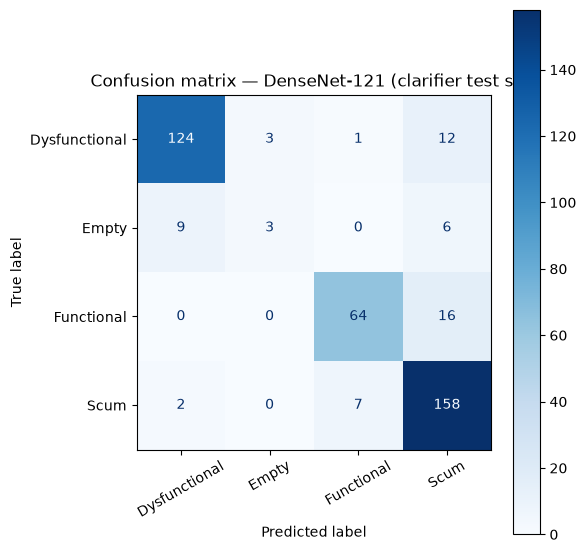

               precision    recall  f1-score   support

Dysfunctional      0.919     0.886     0.902       140
        Empty      0.500     0.167     0.250        18
   Functional      0.889     0.800     0.842        80
         Scum      0.823     0.946     0.880       167

     accuracy                          0.862       405
    macro avg      0.783     0.700     0.719       405
 weighted avg      0.855     0.862     0.852       405



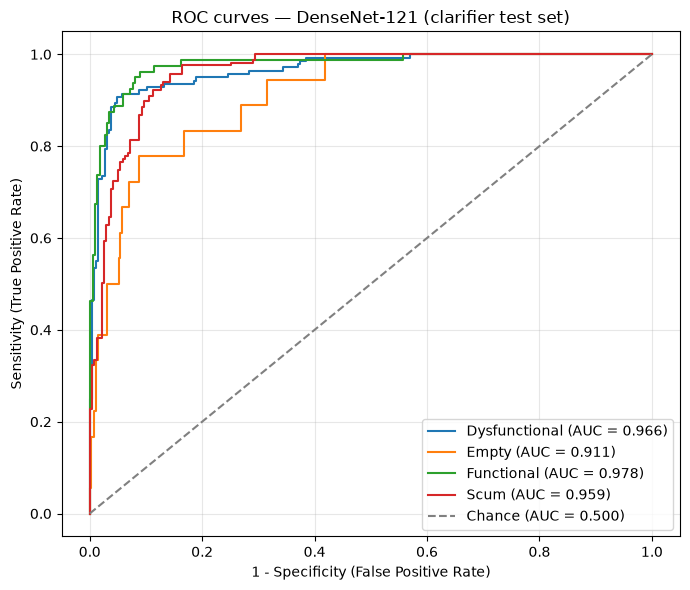

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.966
  Empty          : 0.911
  Functional     : 0.978
  Scum           : 0.959

Mean AUC (over 4/4 classes with test examples): 0.954


(np.float64(0.8617283950617284),
 {'Dysfunctional': 0.9661725067385445,
  'Empty': 0.9109962675854149,
  'Functional': 0.9777307692307692,
  'Scum': 0.9592160217380364})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
